# 🧠 Tarea Semana 2: Optimización de hiperparámetros de Redes Neuronales

Este notebook está diseñado para resolver un problema supervisado (regresión) utilizando un modelo de red neuronal `MLPRegressor`, y aplicar optimización de hiperparámetros (grid search) con validación cruzada (10 folds).


## 📝 Instrucciones 

1. **Carga del conjunto de datos**
   Utiliza el conjunto de datos **Breast Cancer Wisconsin** disponible en el siguiente enlace:
   [https://raw.githubusercontent.com/marsgr6/rna-online/refs/heads/main/data/breast\_cancer.csv](https://raw.githubusercontent.com/marsgr6/rna-online/refs/heads/main/data/breast_cancer.csv)

2. **Preprocesamiento básico**

   * Verifica los tipos de datos.
   * Estándariza las variables numéricas si es necesario.
   * Divide el conjunto en entrenamiento y prueba (por ejemplo, 80%/20%).

3. **Diseña un modelo de red neuronal (MLPClassifier)** y **Optimiza los hiperparámetros**

   * Utiliza `scikit-learn` y usa `GridSearchCV` con validación cruzada de **10 folds** para encontrar la mejor combinación de hiperparámetros (`activation`, `hidden_layer_sizes`, etc.).

4. **Entrenamiento y evaluación del modelo**

   * Entrena el modelo óptimo con el conjunto de hiperparámetros del mejor modelo.
   * Evalúalo para los 10 folds.

5. **Métricas de desempeño en un conjunto de prueba**

   * Calcula y visualiza la **matriz de confusión**.
   * Reporta las métricas: **precisión (accuracy)**, **recall**, **F1-score**.
   * Utiliza `classification_report` y `confusion_matrix` de `sklearn`.

6. **Análisis de resultados**

   * Comenta brevemente los resultados obtenidos.
   * ¿Qué observas sobre el desempeño del modelo? ¿Qué métricas destacan?


### ⏰ Tiempo estimado para completar la actividad: 2 horas

## 🧠 **Opción 1: Low Code — Clasificación con MLPClassifier y Optimización de hiperparámetros**

En esta tarea trabajarás con un conjunto de datos de cáncer de mama y aplicarás una red neuronal multicapa (**MLPClassifier**) usando un **pipeline**, con búsqueda de los mejores hiperparámetros mediante validación cruzada.

Solo necesitarás modificar algunas partes específicas del código indicadas con `# 👈 CAMBIA AQUÍ`.

### 📌 1. Cargar los datos y explorar la variable objetivo

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar los datos desde GitHub
df = pd.read_csv("https://raw.githubusercontent.com/marsgr6/rna-online/refs/heads/main/data/breast_cancer.csv")
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,maligno


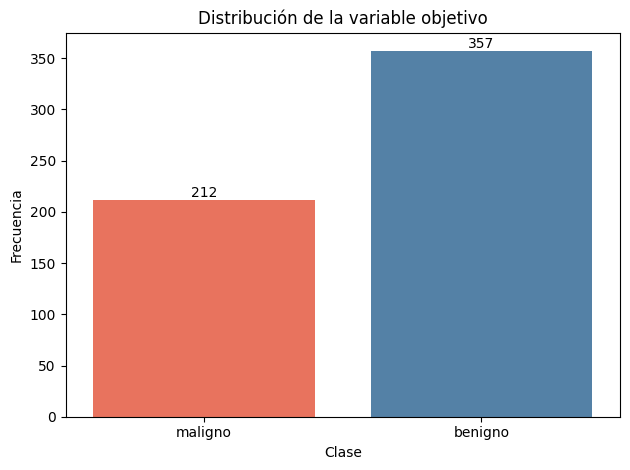

In [6]:
# Visualizar el conteo de ejemplos por clase de la variable objetivo
#plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df,
    x="target",   # 👈 CAMBIA AQUÍ si tu variable objetivo tiene otro nombre
    hue="target",
    palette={'maligno': 'tomato', 'benigno': 'steelblue'}
)

for container in ax.containers:
    ax.bar_label(
        container, 
        label_type='edge', # label_type puede ser 'center' o 'edge'
        #padding=2 # Espacio entre la barra y la etiqueta
    ) 
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.tight_layout()

### 🧪 2. Separar conjunto de entrenamiento y prueba

In [7]:
from sklearn.model_selection import train_test_split

# Separar variables predictoras y objetivo
X = df.drop(columns='target')  # 👈 CAMBIA AQUÍ si tu variable objetivo tiene otro nombre
y = df['target']

# Partición del dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.3, 
    stratify=y, # Mantener la proporción de clases en ambos conjuntos
    random_state=42
)

### ⚙️ 3. Pipeline y optimización con validación cruzada

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Crear pipeline: escalador + red neuronal
pipe = make_pipeline(
    StandardScaler(),
    MLPClassifier(max_iter=1000, random_state=42)
)

# Definir hiperparámetros a probar
param_grid = {
    'mlpclassifier__hidden_layer_sizes': [(50,), (100,), (200,)],  # 👈 CAMBIA AQUÍ las neuronas en la capa oculta, 50,100,200
    'mlpclassifier__activation': ['relu', 'tanh'],  # 👈 CAMBIA AQUÍ la activation function, puedes probar 'relu', 'tanh'
    'mlpclassifier__alpha': [0.0001, 0.001, 0.01]  # 👈 Regularización L2
}

# param_grid = {'mlpclassifier__hidden_layer_sizes': [(50,), (100,), (200,), (50,50), (100,100), (200,200), (50,50,50), (100,100,100), (200,200,200)]}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Buscar los mejores parámetros
grid = GridSearchCV(pipe, param_grid=param_grid, cv=cv, scoring='f1_macro', n_jobs=-1) # n_jobs=-1 para usar todos los núcleos disponibles
grid.fit(X_train, y_train)  # 👈 CAMBIA AQUÍ X_train, y_train

# Mostrar el mejor modelo
print("Mejores hiperparámetros encontrados:")
print(grid.best_params_)

/usr/local/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/local/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/local/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://se

Mejores hiperparámetros encontrados:
{'mlpclassifier__activation': 'relu', 'mlpclassifier__alpha': 0.0001, 'mlpclassifier__hidden_layer_sizes': (200,)}


1. **Validación cruzada de 10 folds** usando `cross_val_score` sobre el **mejor modelo encontrado**.
2. **Visualización con boxplot** de las métricas.
3. **Tabla de métricas promedio y desviación estándar**.


### 📊 4. Evaluación con validación cruzada y visualización de métricas

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extraer el mejor modelo del GridSearchCV
best_model = grid.best_estimator_

# Validación cruzada con 10 folds para distintas métricas
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_scores = {}

for metric in scoring:
    scores = cross_val_score(best_model, X_train, y_train,  # 👈 CAMBIA AQUÍ X_train, y_train
                             cv=10, scoring=metric, n_jobs=-1)
    cv_scores[metric] = scores

# Convertir a DataFrame
cv_df = pd.DataFrame(cv_scores)

# Mostrar resumen
summary = cv_df.agg(['mean', 'std']).T
print("\nResumen de métricas con validación cruzada (10 folds):")
print(summary)

# Convertir a formato largo para graficar
df_long = cv_df.melt(var_name="Métrica", value_name="Puntaje")

# Crear la figura
plt.figure(figsize=(10, 6))

# Boxplot + stripplot + línea de la media
sns.violinplot(data=df_long, x="Métrica", y="Puntaje", hue="Métrica", alpha=.3, cut=0, inner='quartil')
sns.stripplot(data=df_long, x="Métrica", y="Puntaje", hue="Métrica", size=6, alpha=0.6)
# Agregar líneas de medias y barras de error
sns.lineplot(data=df_long, x="Métrica", y="Puntaje", err_style='bars')

# Etiquetas y estilo
plt.title("Distribución de métricas (10-fold CV)")
plt.ylabel("Puntaje")
plt.xlabel("Métrica")
#plt.ylim(0.6, 1.05)
#plt.grid(True)
plt.tight_layout()

NameError: name 'grid' is not defined

### 🧪 5. Evaluación final en conjunto de prueba

In [ ]:
# Predecir sobre el conjunto de prueba
y_pred = best_model.predict(X_test)

# Reporte de clasificación
print("\nReporte de clasificación (conjunto de prueba):\n")
print(classification_report(y_prueba, y_pred))  # 👈 CAMBIA AQUÍ y_test, y_pred

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Benigno', 'Maligno'],
    cmap='Blues',
    colorbar=False
)
plt.title("Matriz de confusión (conjunto de prueba)")
plt.grid(False)
plt.tight_layout()

### ✅ Recomendaciones finales

* Comenta cada bloque que modifiques.
* Puedes probar con diferentes:

  * Variables predictoras
  * Porcentajes de partición
  * Configuraciones de capas ocultas
  * Funciones de activación

### 💬 Reflexión

Comenta brevemente los resultados obtenidos:

* ¿El modelo clasificó correctamente la mayoría de los casos?
* ¿Qué métricas destacan?
* ¿Qué podrías mejorar en una siguiente iteración?

## 🧠 Opción 2: Clasificación con Redes Neuronales (Informe Ejecutivo)

Esta actividad tiene como objetivo aplicar un modelo de red neuronal multicapa para resolver un problema de clasificación binaria (detección de tumores benignos o malignos). El análisis se realiza sobre el conjunto de datos **Breast Cancer Wisconsin**.

## 📝 Instrucciones

### 1. **Exploración inicial del conjunto de datos**

Revisa la distribución de la variable objetivo. Analiza el gráfico adjunto que muestra la cantidad de casos **malignos** y **benignos**.

🧩 **Actividad**:

* ¿Está balanceado el conjunto de datos?
* ¿Por qué puede ser importante considerar el balance de clases en un modelo de clasificación?

<img src="https://raw.githubusercontent.com/marsgr6/r-scripts/refs/heads/master/imgs/ts1_bc_f.png" alt="drawing" width="500"/>

### 2. **Proceso de entrenamiento y validación**

Explica con tus palabras en qué consiste el proceso de dividir el conjunto de datos en **entrenamiento** y **prueba**. Describe también qué significa realizar una **validación cruzada de 10 folds**.

🧩 **Actividad**:

* ¿Por qué es útil separar los datos en entrenamiento y prueba?
* ¿Qué ventajas ofrece la validación cruzada?


### 3. **Optimización del modelo: selección de hiperparámetros**

Se entrenó un modelo de red neuronal (`MLPClassifier`) aplicando una **búsqueda en malla (Grid Search)** con validación cruzada estratificada de 10 folds. Esta técnica permite probar distintas combinaciones de parámetros del modelo para encontrar la que maximiza el rendimiento.

Los **hiperparámetros explorados** fueron:

| Hiperparámetro       | Valores considerados  | Descripción breve                                    |
| -------------------- | --------------------- | ---------------------------------------------------- |
| `hidden_layer_sizes` | (50,), (100,), (200,) | Cantidad de neuronas en la capa oculta               |
| `activation`         | `'relu'`, `'tanh'`    | Función de activación utilizada en las neuronas      |
| `alpha`              | 0.0001, 0.001, 0.01   | Coeficiente de regularización L2 (evita sobreajuste) |

🧠 **Mejor configuración encontrada**:

```python
{'mlpclassifier__activation': 'relu', 'mlpclassifier__alpha': 0.0001, 'mlpclassifier__hidden_layer_sizes': (200,)}
```

🧩 **Actividad**:

* Explica qué rol juega cada uno de estos hiperparámetros en el entrenamiento de una red neuronal.
* ¿Qué podría indicar que la mejor configuración tenga 200 neuronas y use `relu`?
* ¿Qué importancia tiene el valor bajo de `alpha` en este caso?


### 4. **Evaluación con validación cruzada (10 folds)**

Se calcularon métricas de desempeño en validación cruzada utilizando los siguientes indicadores:

| Métrica              | Media  | Desviación estándar |
| -------------------- | ------ | ------------------- |
| **Accuracy**         | 0.9823 | 0.0172              |
| **Precision\_macro** | 0.9855 | 0.0138              |
| **Recall\_macro**    | 0.9773 | 0.0235              |
| **F1\_macro**        | 0.9807 | 0.0191              |

<img src="https://raw.githubusercontent.com/marsgr6/r-scripts/refs/heads/master/imgs/vprnats2.png" alt="drawing" width="900"/>

🧩 **Actividad**:

* Interpreta los valores promedio y su dispersión.
* ¿Qué te indica el gráfico de violines sobre la estabilidad de cada métrica?


### 5. **Evaluación en el conjunto de prueba**

Se evaluó el desempeño del modelo entrenado sobre el 30% del conjunto de datos reservado para prueba. Aquí están las métricas:

📄 **Reporte de clasificación (conjunto de prueba)**:

| Clase              | Precision | Recall | F1-score | Soporte |
| ------------------ | --------- | ------ | -------- | ------- |
| Benigno            | 0.96      | 1.00   | 0.98     | 107     |
| Maligno            | 1.00      | 0.92   | 0.96     | 64      |
| **Accuracy**: 0.97 |           |        |          |         |

<img src="https://raw.githubusercontent.com/marsgr6/r-scripts/refs/heads/master/imgs/cmrnats2.png" alt="drawing" width="500"/>

🧩 **Actividad**:

* ¿Cómo interpretar la matriz de confusión? ¿Qué tipos de error se observan?
* ¿Cuál es el desempeño del modelo para cada clase?
* ¿Cuál métrica destacarías como más relevante en un problema de salud como este?


### 6. **Reflexión final**

🧩 **Actividad**:

* ¿Consideras que el modelo es adecuado para este tipo de problema?
* ¿Qué mejorarías o explorarías en una siguiente iteración? (por ejemplo, otros modelos, nuevas variables, balanceo de clases, más datos, etc.)


⏱️ **Tiempo estimado de desarrollo**: 2 horas
✍️ **Entrega**: Informe ejecutivo con respuestas a cada sección y discusión de los gráficos presentados.

## 🧠 **Opción 3 – Libre elección de dataset y optimización de hiperparámetros**

En esta tarea, el estudiante podrá **seleccionar el conjunto de datos** con el que desea trabajar.

* Si no dispone de un dataset, se recomienda utilizar **MNIST** como referencia.
* Se sugiere escoger un problema de **clasificación o regresión propio**, siempre que **no se repita** alguno de los datasets ya empleados en el contenido y ejercicios del curso (ej.: Breast Cancer, Diabetes, Fashion-MNIST, Bike Sharing, Fraud Detection).
* El trabajo puede desarrollarse en **Google Colab**, asistido por **Gemini AI**, ya sea en modalidad **high-code** (escribir el código completo) o **no-code** (apoyarse más en Gemini para generar bloques de código automáticamente).


#### 📌 1. Cargar y explorar los datos

* Subir el archivo CSV/Excel o importar el dataset desde una librería pública (`sklearn.datasets`, `tensorflow.keras.datasets`, `openml`, etc.).


#### ⚙️ 2. Preparar el conjunto de datos

* Definir variables predictoras (**X**) y la variable objetivo (**y**).
* Dividir en **entrenamiento y prueba** (`train_test_split`).
* Normalizar características numéricas con `StandardScaler` u otra técnica adecuada.


#### 🤖 3. Seleccionar modelo y definir hiperparámetros

* Para **clasificación**: `MLPClassifier`
* Para **regresión**: `MLPRegressor`
* Definir un espacio de búsqueda de hiperparámetros, por ejemplo:

  * Número de neuronas ocultas (`hidden_layer_sizes`)
  * Funciones de activación (`activation`)
  * Parámetro de regularización (`alpha`)

👉 Con **Gemini**, se puede pedir:
*"Genera un pipeline con StandardScaler y MLPClassifier, y aplica GridSearchCV con 10 folds."*


#### 📊 4. Optimización con validación cruzada

* Usar `GridSearchCV` (o `RandomizedSearchCV`) con **validación cruzada de 10 folds**.
* Reportar los **mejores hiperparámetros encontrados** (`best_params_`).
* Evaluar el rendimiento con métricas adecuadas:

  * **Clasificación** → accuracy, precision, recall, F1.
  * **Regresión** → MAE, RMSE, R².
* Visualizar resultados con gráficos:

  * Boxplot o violinplot para las métricas en cada fold.
  * Matriz de confusión (clasificación) o dispersión `y_true vs y_pred` (regresión).



#### ✅ Recomendaciones finales

* Comenta cada bloque de código generado o modificado.
* Documenta brevemente:

  * ¿Por qué se eligió ese dataset?
  * ¿Qué hiperparámetros resultaron más relevantes?
  * ¿Qué métricas destacan del modelo entrenado?
  * ¿Qué posibles mejoras se implementarían en una segunda iteración?

## 🧠 **Opción 4 – Libre elección de dataset en KNIME con optimización de hiperparámetros**

En esta tarea, el estudiante podrá **seleccionar el dataset** con el que desea trabajar en KNIME.

* Si no cuenta con un dataset propio, se recomienda utilizar **MNIST** (para clasificación) o un dataset público de regresión disponible en [UCI Machine Learning Repository](https://archive.ics.uci.edu/).
* La consigna es plantear un problema de **clasificación o regresión**, diferente de los datasets ya usados en el curso.
* El flujo debe incluir **optimización de hiperparámetros** y **validación cruzada (Cross Validation)** para redes neuronales (MLP).


#### 📌 1. Importación de datos

* Utilizar el nodo **File Reader** o **Excel Reader** para cargar el dataset.
* Verificar nombres de columnas y tipos de datos con **Data Explorer**.


#### ⚙️ 2. Preprocesamiento

* Normalización con **Normalizer** (para X y, si aplica, también para y).
* División en entrenamiento y prueba con **Partitioning**.


#### 🤖 3. Modelado con optimización de hiperparámetros

* Para **clasificación**:

  * Nodo **Parameter Optimization Loop Start** → configurar hiperparámetros (ej. número de neuronas, función de activación, tasa de aprendizaje).
  * Nodo **Cross Validation** con **MLP Learner**.
  * Nodo **Parameter Optimization Loop End** para seleccionar el mejor modelo.

![](https://raw.githubusercontent.com/marsgr6/r-scripts/refs/heads/master/imgs/KNIME_hyperparams_classification.png)

* Para **regresión**:

  * Nodo **Parameter Optimization Loop Start** + **Cross Validation** con **MLP Learner (Regresión)**.
  * Cierre con **Parameter Optimization Loop End**.

![](https://raw.githubusercontent.com/marsgr6/r-scripts/refs/heads/master/imgs/KNIME_hyperparams_regression.png)



#### 📊 4. Evaluación

* **Clasificación**: usar **Scorer** para matriz de confusión, accuracy, precision y recall.
* **Regresión**: usar **Numeric Scorer** para MAE, RMSE y R².
* Comparar métricas de validación cruzada y del conjunto de prueba.


#### ✅ Recomendaciones finales

* Documentar el flujo KNIME con **Annotation nodes** para explicar cada bloque.
* Guardar capturas del flujo completo y de los resultados principales.
* Reflexionar:

  * ¿Qué hiperparámetros fueron más relevantes en la optimización?
  * ¿Qué métricas destacan del modelo?
  * ¿Cómo se podría mejorar el desempeño en una segunda iteración?